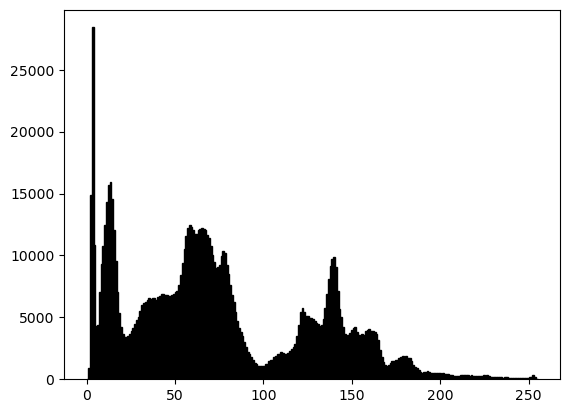

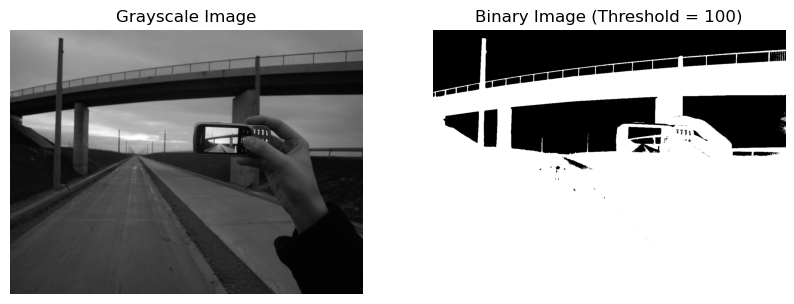

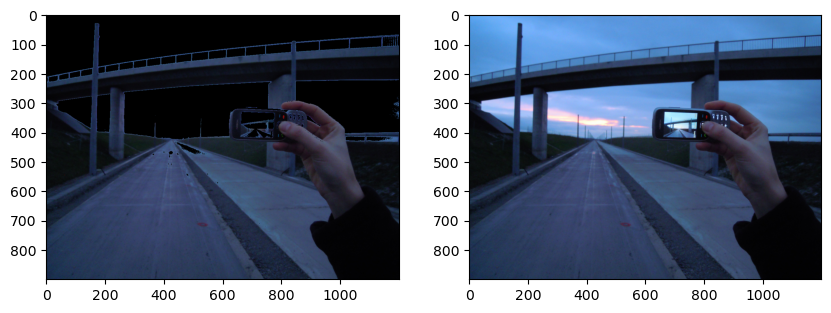

In [7]:
from PIL import Image
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# Open the image file
image = Image.open("image.png")

real_image_array = np.array(image)

# Convert the image to grayscale
gray_image = image.convert("L")

# Convert the grayscale image to an array
gray_image_array = np.array(gray_image)

plt.hist(gray_image_array.ravel(), bins=256, range=(0.0, 255.0), fc='k', ec='k')

# Threshold the grayscale image
threshold = 100
binary_image_array = np.where(gray_image_array < threshold, 1, 0)

# Convert the array to a new image
binary_image = Image.fromarray(binary_image_array.astype(np.uint8))

# Display the grayscale and binary images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')
axes[1].imshow(binary_image, cmap='gray')
axes[1].set_title('Binary Image (Threshold = {m})'.format(m=threshold))
axes[1].axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Apply the mask to the real image array
new_image_array = real_image_array * binary_image_array[:, :, np.newaxis]

# Convert the array to a new image
new_image = Image.fromarray(new_image_array.astype(np.uint8))

axes[0].imshow(new_image, cmap='gray')
axes[1].imshow(real_image_array, cmap='gray')
plt.show()
